In [1]:
import sys
import importlib
print("sys.executable:", sys.executable)
print("sys.version:", sys.version)
import warp
print("warp module:", warp)
print("warp.__file__:", getattr(warp, "__file__", None))
print("has context:", hasattr(warp, "context"))
print("members containing 'context':", [m for m in dir(warp) if "context" in m.lower()])
print("first 10 sys.path entries:", sys.path[:10])

sys.executable: /scratch/cwilczewski/venv/bin/python
sys.version: 3.11.9 (main, Sep 20 2025, 05:09:43) [GCC 13.3.0]
warp module: <module 'warp' from '/scratch/cwilczewski/venv/lib/python3.11/site-packages/warp/__init__.py'>
warp.__file__: /scratch/cwilczewski/venv/lib/python3.11/site-packages/warp/__init__.py
Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
has context: True
members containing 'context': ['context']
first 10 sys.path entries: ['/apps/arch/2025/software/linux-rhel8-cascadelake/gcc-13.3.0/python-3.11.9-y7fulttvp6obrlg7fu55qwdhcvbhlcrd/lib/python311.zip', '/apps/arch/2025/software/linux-rhel8-cascadelake/gcc-13.3.0/python-3.11.9-y7fulttvp6obrlg7fu55qwdhcvbhlcrd/lib/python3.11', '/apps/arch/2025/software/linux-rhel8-cascadelake/gcc-13.3.0/python-3.11.9-y7fulttvp6obrlg7fu55qwdhcvbhlcrd/lib/python3.11/lib-dynload', '', '/scratch/cwi

In [11]:
from torch.utils.data import DataLoader, Dataset
import torch
# from physicsnemo.datapipes.benchmarks.darcy import Darcy2D
import numpy as np
import matplotlib.pyplot as plt

def plot_batch(batch: list[torch.Tensor]):
    n = len(batch)
    fig, ax = plt.subplots(1, n, figsize=(6 * n, 5))
    ax = np.atleast_1d(ax)

    for i, item in enumerate(batch):
        arr = item[0, 0].cpu()
        vmin = arr.min().item()
        vmax = arr.max().item()
        im = ax[i].imshow(arr, vmin=vmin, vmax=vmax, cmap="bwr", origin="lower")
        plt.colorbar(im, ax=ax[i])
        ax[i].set_title(f"batch[{i}] (min: {vmin:.4e}, max: {vmax:.4e})")

    plt.tight_layout()
    plt.show()

This is the code from the customly generated Darcy flow in the fno example

In [3]:
# (mean, std) for normalisation
normaliser = {
        "permeability": (1.25, 0.75),
        "darcy": (4.52e-2, 2.79e-2),
    }

dataloader = Darcy2D(
        resolution=240,
        batch_size=1,
        normaliser=normaliser,
        device="cpu"
    )

In [4]:
batch = next(iter(dataloader))
print(type(batch))

<class 'dict'>


Batch keys: dict_keys(['permeability', 'darcy'])
Batch shapes: {'permeability': torch.Size([1, 1, 240, 240]), 'darcy': torch.Size([1, 1, 240, 240])}
permeability - dtype: torch.float32, device: cpu
permeability - min: -1.0, max: 1.0
permeability - mean: -0.3097916543483734, std: 0.9508126974105835
darcy - dtype: torch.float32, device: cpu
darcy - min: -1.6163666248321533, max: 2.6082324981689453
darcy - mean: 0.35117363929748535, std: 1.2123150825500488
tensor([[[[-1.6164, -1.6133, -1.6106,  ..., -1.6093, -1.6115, -1.6139],
          [-1.6133, -1.6073, -1.6020,  ..., -1.5996, -1.6038, -1.6085],
          [-1.6106, -1.6020, -1.5943,  ..., -1.5907, -1.5970, -1.6038],
          ...,
          [-1.6095, -1.5999, -1.5912,  ..., -1.5753, -1.5852, -1.5959],
          [-1.6116, -1.6041, -1.5974,  ..., -1.5852, -1.5928, -1.6011],
          [-1.6140, -1.6087, -1.6041,  ..., -1.5959, -1.6011, -1.6067]]]])


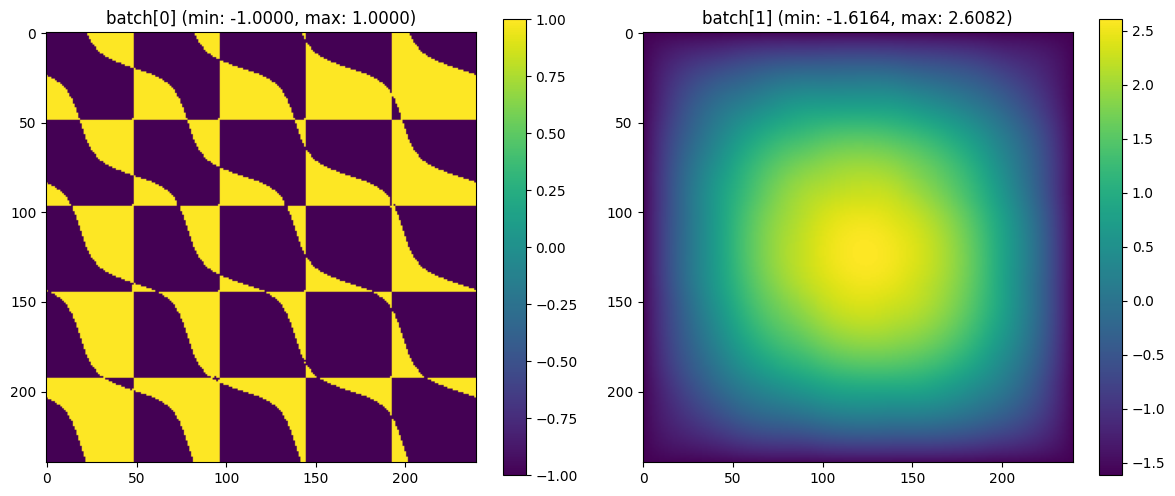

In [5]:
def print_batch_info(batch):
    if isinstance(batch, dict):
        print("Batch keys:", batch.keys())
        print("Batch shapes:", {k: v.shape for k, v in batch.items()})
        for k, v in batch.items():
            print(f"{k} - dtype: {v.dtype}, device: {v.device}")
            print(f"{k} - min: {v.min().item()}, max: {v.max().item()}")
            print(f"{k} - mean: {v.mean().item()}, std: {v.std().item()}")
    elif isinstance(batch, (list, tuple)):
        print("Batch is a list/tuple with length:", len(batch))
        for i, item in enumerate(batch):
            print(f"Item {i} - type: {type(item)}, shape: {item.shape}, dtype: {item.dtype}, device: {item.device}")
            print(f"Item {i} - min: {item.min().item()}, max: {item.max().item()}")
            print(f"Item {i} - mean: {item.mean().item()}, std: {item.std().item()}")
print_batch_info(batch)
print(batch['darcy'])
plot_batch(list(batch.values()))

This is the data from the Neural Operator dataset
Example: darcy_physics_informed

In [22]:
import torch
import h5py
from typing import Union
class HDF5MapStyleDataset(Dataset):
    """Simple map-style HDF5 dataset"""

    def __init__(
        self,
        file_path,
        device: Union[str, torch.device] = "cuda",
    ):
        self.file_path = file_path
        with h5py.File(file_path, "r") as f:
            self.keys = list(f.keys())

        # Set up device, needed for pipeline
        if isinstance(device, str):
            device = torch.device(device)
        # Need a index id if cuda
        if device.type == "cuda" and device.index == None:
            device = torch.device("cuda:0")
        self.device = device

    def __len__(self):
        with h5py.File(self.file_path, "r") as f:
            return len(f[self.keys[0]])

    def __getitem__(self, idx):
        res = 240
        data = {}
        with h5py.File(self.file_path, "r") as f:
            for key in self.keys:
                data[key] = np.array(f[key][idx])
        output = {}
        
        
        output["permeability"] = torch.from_numpy((data["Kcoeff"][:, :res, :res]) / 4.49996e00)
        output["K__x"] = torch.from_numpy(data["Kcoeff_x"][:, :res, :res]) / 4.49996e00
        output["K__y"] = torch.from_numpy(data["Kcoeff_y"][:, :res, :res]) / 4.49996e00
  
        output["darcy"] = torch.from_numpy((data["sol"][:, :res, :res]) / 3.88433e-03)
    

        x = np.linspace(0, 1, res)
        y = np.linspace(0, 1, res)

        xx, yy = np.meshgrid(x, y)
        output["x_invar"] = torch.from_numpy(xx.astype(np.float32)).view(
            1, res, res
        )  # add channel dimension
        output["y_invar"] = torch.from_numpy(yy.astype(np.float32)).view(
            1, res, res
        )  # add channel dimension

        if self.device.type == "cuda":
            # Move tensors to GPU
            for key, tensor in output.items():
                output[key] = tensor.cuda()

        return output


In [23]:
from hydra.utils import to_absolute_path
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
dataset = HDF5MapStyleDataset(
        to_absolute_path("./datasets/Darcy_241/train.hdf5"), device=device
    )

dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

In [24]:
batch = next(iter(dataloader))
print(type(batch))

<class 'dict'>


In [92]:
path = "datasets/Darcy_241/piececonst_r241_N1024_smooth1.hdf5"
def print_keys(path):
    with h5py.File(path, "r") as f:
        for key in f.keys():
            a = np.array(f[key])   # shape (N,C,H,W)
            print(key, "mean:", a.mean(), "std:", a.std())
print_keys(path)

Kcoeff mean: 7.485814 std: 4.356923
Kcoeff_x mean: 0.013325771 std: 24.290697
Kcoeff_y mean: -0.16914834 std: 24.416859
coeff mean: 7.4858108 std: 4.4999776
sol mean: 0.005743183 std: 0.003884709


6
Batch keys: dict_keys(['permeability', 'K__x', 'K__y', 'darcy', 'x_invar', 'y_invar'])
Batch shapes: {'permeability': torch.Size([1, 1, 240, 240]), 'K__x': torch.Size([1, 1, 240, 240]), 'K__y': torch.Size([1, 1, 240, 240]), 'darcy': torch.Size([1, 1, 240, 240]), 'x_invar': torch.Size([1, 1, 240, 240]), 'y_invar': torch.Size([1, 1, 240, 240])}
permeability - dtype: torch.float32, device: cpu
permeability - min: 0.6666725277900696, max: 2.6666901111602783


permeability - mean: 1.7175716161727905, std: 0.9734532237052917
K__x - dtype: torch.float32, device: cpu
K__x - min: -32.76010513305664, max: 29.316253662109375
K__x - mean: -1.6666812896728516, std: 6.174998760223389
K__y - dtype: torch.float32, device: cpu
K__y - min: -16.401033401489258, max: 32.710792541503906
K__y - mean: 0.27811411023139954, std: 2.2913589477539062
darcy - dtype: torch.float32, device: cpu
darcy - min: 0.00036744546378031373, max: 3.4515063762664795
darcy - mean: 1.438173532485962, std: 0.9465898871421814
x_invar - dtype: torch.float32, device: cpu
x_invar - min: 0.0, max: 1.0
x_invar - mean: 0.5, std: 0.28988298773765564
y_invar - dtype: torch.float32, device: cpu
y_invar - min: 0.0, max: 1.0
y_invar - mean: 0.5, std: 0.28988298773765564


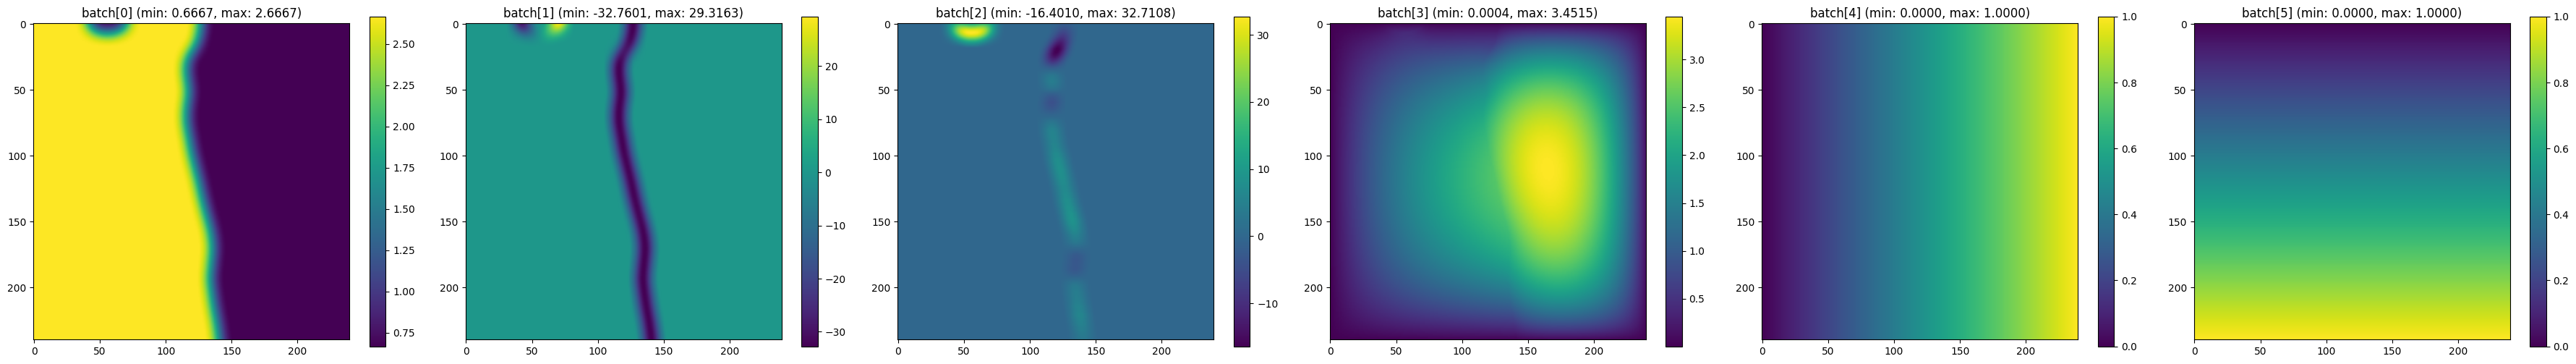

In [25]:
print(len(batch))
print_batch_info(batch)

plot_batch(list(batch.values()))

Precomputed data and loaded
Batch keys: dict_keys(['permeability', 'K__x', 'K__y', 'darcy', 'x_invar', 'y_invar'])
Batch shapes: {'permeability': torch.Size([1, 1, 240, 240]), 'K__x': torch.Size([1, 1, 240, 240]), 'K__y': torch.Size([1, 1, 240, 240]), 'darcy': torch.Size([1, 1, 240, 240]), 'x_invar': torch.Size([1, 1, 240, 240]), 'y_invar': torch.Size([1, 1, 240, 240])}
permeability - dtype: torch.float32, device: cpu
permeability - min: 0.6666725277900696, max: 2.6666901111602783
permeability - mean: 1.7175716161727905, std: 0.9734532237052917
K__x - dtype: torch.float32, device: cpu
K__x - min: -32.76010513305664, max: 29.316253662109375
K__x - mean: -1.6666812896728516, std: 6.174998760223389
K__y - dtype: torch.float32, device: cpu
K__y - min: -16.401033401489258, max: 32.710792541503906
K__y - mean: 0.27811411023139954, std: 2.2913589477539062
darcy - dtype: torch.float32, device: cpu
darcy - min: 0.00036744546378031373, max: 3.4515063762664795
darcy - mean: 1.438173532485962, std: 0.9465898871421814
x_invar - dtype: torch.float32, device: cpu
x_invar - min: 0.0, max: 1.0
x_invar - mean: 0.5, std: 0.28988298773765564
y_invar - dtype: torch.float32, device: cpu
y_invar - min: 0.0, max: 1.0
y_invar - mean: 0.5, std: 0.28988298773765564

Physics NeMo benchmark "permeability": (1.25, 0.75), "darcy": (4.52e-2, 2.79e-2),
Batch keys: dict_keys(['permeability', 'darcy'])
Batch shapes: {'permeability': torch.Size([1, 1, 240, 240]), 'darcy': torch.Size([1, 1, 240, 240])}
permeability - dtype: torch.float32, device: cpu
permeability - min: -1.0, max: 1.0
permeability - mean: -0.3097916543483734, std: 0.9508126974105835
darcy - dtype: torch.float32, device: cpu
darcy - min: -1.6163666248321533, max: 2.6082324981689453
darcy - mean: 0.35117363929748535, std: 1.2123150825500488

This is from the Physics NeMo Sym example (PINO)

In [27]:
def load_FNO_dataset(path, input_keys, output_keys, n_examples=None):
    "Loads a FNO dataset"

    if not path.endswith(".hdf5"):
        raise Exception(
            ".hdf5 file required: please use utilities.preprocess_FNO_mat to convert .mat file"
        )

    # load data
    path = to_absolute_path(path)
    data = h5py.File(path, "r")
    _ks = [k for k in data.keys() if not k.startswith("__")]
    print(f"loaded: {path}\navaliable keys: {_ks}")

    # parse data
    invar, outvar = dict(), dict()
    for d, keys in [(invar, input_keys), (outvar, output_keys)]:
        for k in keys:
            # get data
            x = data[k]  # N, C, H, W

            # cut examples out
            if n_examples is not None:
                x = x[:n_examples]

            # print out normalisation values
            print(f"selected key: {k}, mean: {x.mean():.5e}, std: {x.std():.5e}")

            d[k] = x
    del data

    return (invar, outvar)

In [44]:
from physicsnemo.sym.dataset import DictGridDataset
from physicsnemo.sym.key import Key
input_keys = [
        Key("coeff", scale=(7.48360e00, 4.49996e00)),
        Key("Kcoeff_x"),
        Key("Kcoeff_y"),
    ]
output_keys = [
    Key("sol", scale=(5.74634e-03, 3.88433e-03)),
]


invar_train, outvar_train = load_FNO_dataset(
    "datasets/Darcy_241/piececonst_r241_N1024_smooth1.hdf5",
    [k.name for k in input_keys],
    [k.name for k in output_keys],
    n_examples=10,
)

# add additional constraining values for darcy variable
outvar_train["darcy"] = np.zeros_like(outvar_train["sol"])

print("invar_train keys:", invar_train.keys())
print("outvar_train keys:", outvar_train.keys())
print(f"Invar coeff shape: {invar_train['coeff'].shape}")
print(f"Outvar sol shape: {outvar_train['sol'].shape}")

train_dataset = DictGridDataset(invar_train, outvar_train)

loaded: /scratch/cwilczewski/physicsnemo/temp/datasets/Darcy_241/piececonst_r241_N1024_smooth1.hdf5
avaliable keys: ['Kcoeff', 'Kcoeff_x', 'Kcoeff_y', 'coeff', 'sol']
selected key: coeff, mean: 7.43340e+00, std: 4.49951e+00
selected key: Kcoeff_x, mean: -1.69548e+00, std: 2.59183e+01
selected key: Kcoeff_y, mean: 3.52966e-01, std: 2.26482e+01
selected key: sol, mean: 5.82796e-03, std: 4.01878e-03
invar_train keys: dict_keys(['coeff', 'Kcoeff_x', 'Kcoeff_y'])
outvar_train keys: dict_keys(['sol', 'darcy'])
Invar coeff shape: (10, 1, 241, 241)
Outvar sol shape: (10, 1, 241, 241)


In [43]:
batch = next(iter(train_dataset))
print(len(batch))
for i, item in enumerate(batch):
    print(f"Item {i} type: {type(item)}")
    for k, v in item.items():
        print(f"{k} - shape: {v.shape}, dtype: {v.dtype}, min: {v.min()}, max: {v.max()}")
        print(f"{k} - mean: {v.mean().item()}, std: {v.std().item()}")

3
Item 0 type: <class 'dict'>
coeff - shape: torch.Size([1, 241, 241]), dtype: torch.float32, min: 3.0, max: 12.0
coeff - mean: 7.648370265960693, std: 4.497591972351074
Kcoeff_x - shape: torch.Size([1, 241, 241]), dtype: torch.float32, min: 0.0, max: 147.41921997070312
Kcoeff_x - mean: 7.468879222869873, std: 26.831483840942383
Kcoeff_y - shape: torch.Size([1, 241, 241]), dtype: torch.float32, min: -81.08577728271484, max: 51.26423645019531
Kcoeff_y - mean: -0.9730770587921143, std: 8.479391098022461
Item 1 type: <class 'dict'>
sol - shape: torch.Size([1, 241, 241]), dtype: torch.float32, min: 1.3711057817999972e-06, max: 0.013709244318306446
sol - mean: 0.005553640890866518, std: 0.0037776934914290905
darcy - shape: torch.Size([1, 241, 241]), dtype: torch.float32, min: 0.0, max: 0.0
darcy - mean: 0.0, std: 0.0
Item 2 type: <class 'dict'>
sol - shape: torch.Size([1, 241, 241]), dtype: torch.float32, min: 1.0, max: 1.0
sol - mean: 1.0, std: 0.0
darcy - shape: torch.Size([1, 241, 241]),

In [53]:
from physicsnemo.sym.dataset import HDF5GridDataset

dataset = HDF5GridDataset(
    "datasets/Darcy_241/piececonst_r241_N1024_smooth1.hdf5",
    [k.name for k in input_keys],
    [k.name for k in output_keys],
    n_examples=100,
)

dataloader = DataLoader(dataset, num_workers=1, batch_size=1, shuffle=True, worker_init_fn=dataset.worker_init_fn)

batch = next(iter(dataloader))
print(len(batch))
invar, outvar, weights = batch
print("invar keys:", invar.keys())
print("invar['coeff'] shape:", invar['coeff'].shape, "invar['coeff'] mean:", invar['coeff'].mean().item(), "std:", invar['coeff'].std().item())
print("outvar keys:", outvar.keys())
print("outvar['sol'] shape:", outvar['sol'].shape, "outvar['sol'] mean:", outvar['sol'].mean().item(), "std:", outvar['sol'].std().item())


3
invar keys: dict_keys(['coeff', 'Kcoeff_x', 'Kcoeff_y'])
invar['coeff'] shape: torch.Size([1, 1, 241, 241]) invar['coeff'] mean: 7.4720306396484375 std: 4.4999518394470215
outvar keys: dict_keys(['sol'])
outvar['sol'] shape: torch.Size([1, 1, 241, 241]) outvar['sol'] mean: 0.005759702995419502 std: 0.003955172374844551


In [64]:
path = "DarcyFlow/2D_DarcyFlow_beta0.1_Train.hdf5"
with h5py.File(path, "r") as f:
    print((f['tensor'][0].shape))
    print(f["nu"][0].shape)
dataset = HDF5GridDataset(
    path,
    ["nu"],
    ["tensor"],
    n_examples=100,
)

dataloader = DataLoader(dataset, num_workers=1, batch_size=1, shuffle=True, worker_init_fn=dataset.worker_init_fn)

batch = next(iter(dataloader))
print(len(batch))
invar, outvar, weights = batch
print("invar keys:", invar.keys())
print("invar['nu'] shape:", invar['nu'].shape, "invar['nu'] mean:", invar['nu'].mean().item(), "std:", invar['nu'].std().item())
print("outvar keys:", outvar.keys())
print("outvar['tensor'] shape:", outvar['tensor'].shape, "outvar['tensor'] mean:", outvar['tensor'].mean().item(), "std:", outvar['tensor'].std().item())


(1, 128, 128)
(128, 128)
3
invar keys: dict_keys(['nu'])
invar['nu'] shape: torch.Size([1, 128, 128]) invar['nu'] mean: 0.7757689952850342 std: 0.3892782926559448
outvar keys: dict_keys(['tensor'])
outvar['tensor'] shape: torch.Size([1, 1, 128, 128]) outvar['tensor'] mean: 0.00821148045361042 std: 0.004329676739871502


In [3]:
import torch
import h5py
from typing import Union
class HDF5MapStyleDataset(Dataset):
    """Simple map-style HDF5 dataset"""

    def __init__(
        self,
        file_path,
        device: Union[str, torch.device] = "cuda",
        mappings: dict[str, str] = {
            "permeability": "permeability",
            "darcy": "darcy",
        },
    ):
        self.file_path = file_path
        self.keys = []
        with h5py.File(file_path, "r") as f:
            for k in f.keys():
                if k in mappings.values():
                    self.keys.append(k)

        # Set up device, needed for pipeline
        if isinstance(device, str):
            device = torch.device(device)
        # Need a index id if cuda
        if device.type == "cuda" and device.index == None:
            device = torch.device("cuda:0")
        self.device = device
        self.res = 128
        self.mappings = mappings

    def __len__(self):
        with h5py.File(self.file_path, "r") as f:
            return len(f[self.keys[0]])

    def __getitem__(self, idx):
        res = self.res
        data = {}
        with h5py.File(self.file_path, "r") as f:
            for key in self.keys:
                data[key] = np.array(f[key][idx])
                
        
        output = {}
        
        # Add channel dimension if needed
        for key, value in self.mappings.items():
            print(f"Processing key: {key} mapped to {value}")
            print(f"Accessing data[{value}]")
            if data[value].ndim == 2:
                data[value] = data[value][np.newaxis, :, :]
            output[key] = torch.from_numpy((data[value][:, :res, :res]))
    

        if self.device.type == "cuda":
            # Move tensors to GPU
            for key, tensor in output.items():
                output[key] = tensor.cuda()

        return output


NameError: name 'Dataset' is not defined

Dataset length: 10000
Processing key: permeability mapped to nu
Accessing data[nu]
Processing key: darcy mapped to tensor
Accessing data[tensor]
<class 'dict'>
2
Batch keys: dict_keys(['permeability', 'darcy'])
Batch shapes: {'permeability': torch.Size([1, 1, 128, 128]), 'darcy': torch.Size([1, 1, 128, 128])}
permeability - dtype: torch.float32, device: cpu
permeability - min: 0.10000000149011612, max: 1.0
permeability - mean: 0.5339049100875854, std: 0.44972580671310425
darcy - dtype: torch.float32, device: cpu
darcy - min: 0.0014585827011615038, max: 0.2720000147819519
darcy - mean: 0.15751560032367706, std: 0.07774051278829575


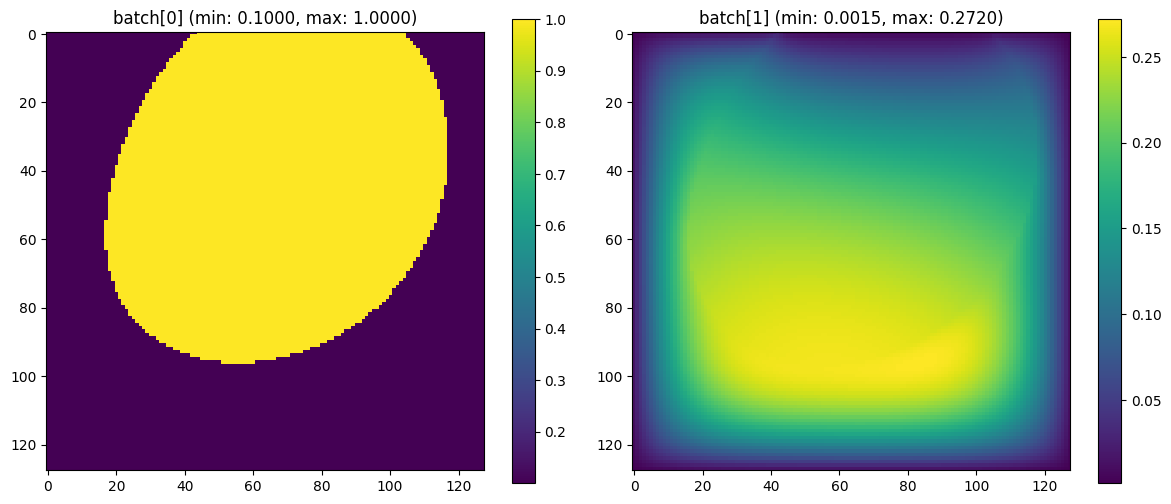

In [103]:
device = torch.device("cpu")
dataset = HDF5MapStyleDataset(
        to_absolute_path("./DarcyFlow/2D_DarcyFlow_beta1.0_Train.hdf5"), device=device,
        mappings={
            "permeability": "nu",
            "darcy": "tensor",
        },
    )
print("Dataset length:", len(dataset))
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
batch = next(iter(dataloader))
print(type(batch))
print(len(batch))
print_batch_info(batch)
plot_batch(list(batch.values()))

In [ ]:

dataset = HDF5MapStyleDataset(
        to_absolute_path("./datasets/Darcy_241/piececonst_r241_N1024_smooth1.hdf5"), device=device,
        mappings={
            "permeability": "coeff",
            "Kpermeability": "Kcoeff",
            "darcy": "sol",
        },
    )
print("Dataset length:", len(dataset))
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
batch = next(iter(dataloader))
print(type(batch))
print(len(batch))
print_batch_info(batch)
plot_batch(list(batch.values()))

for data in dataloader:
    k = data["permeability"]
    u = data["sol"]

NameError: name 'HDF5MapStyleDataset' is not defined

In [2]:
from utils import CustomDataset
from hydra.utils import to_absolute_path
import torch
dataset = CustomDataset(
        to_absolute_path("./datasets/Darcy_241/piececonst_r241_N1024_smooth1.hdf5"),
        mappings={
            "permeability": "coeff",
            "Kpermeability": "Kcoeff",
            "darcy": "sol",
        },
        device=torch.device("cpu"),
    )

selected key: Kcoeff, mean: 7.48581e+00, std: 4.35692e+00
selected key: Kcoeff_x, mean: 1.33258e-02, std: 2.42907e+01
selected key: Kcoeff_y, mean: -1.69148e-01, std: 2.44169e+01
selected key: coeff, mean: 7.48581e+00, std: 4.49998e+00
selected key: sol, mean: 5.74318e-03, std: 3.88471e-03


In [4]:
from torch.utils.data import DataLoader
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
batch = next(iter(dataloader))
print(type(batch))

<class 'dict'>


u shape: torch.Size([1, 1, 240, 240])
Sample shape: torch.Size([1, 240, 240]) max: 0.017388837411999702 min: -5.69676558370702e-05
Sample shape: torch.Size([1, 240, 240]) max: 0.01789364032447338 min: -0.000607726804446429
Sample shape: torch.Size([1, 240, 240]) max: 0.018281936645507812 min: -0.001146252267062664
u_noisy shape: torch.Size([3, 1, 240, 240])


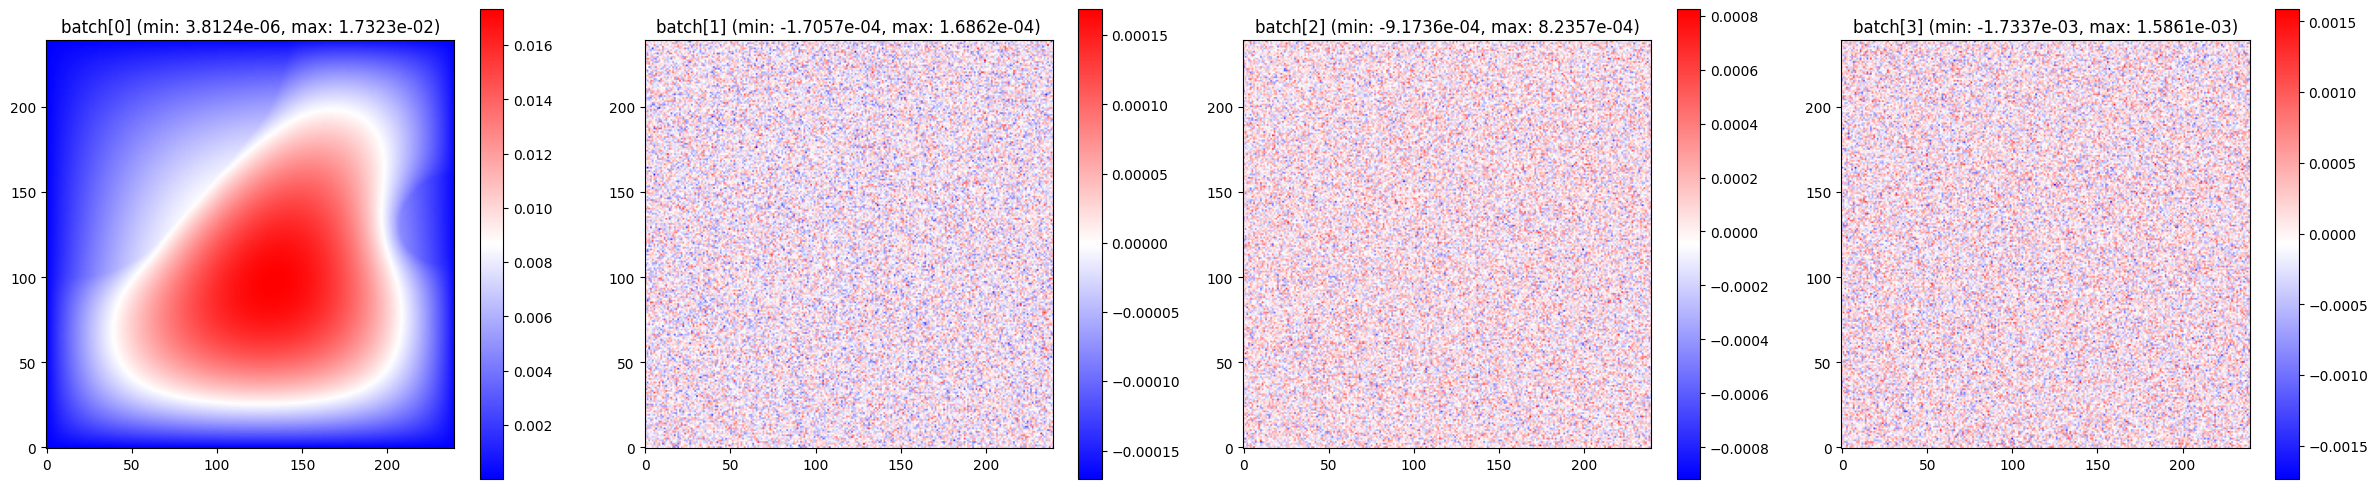

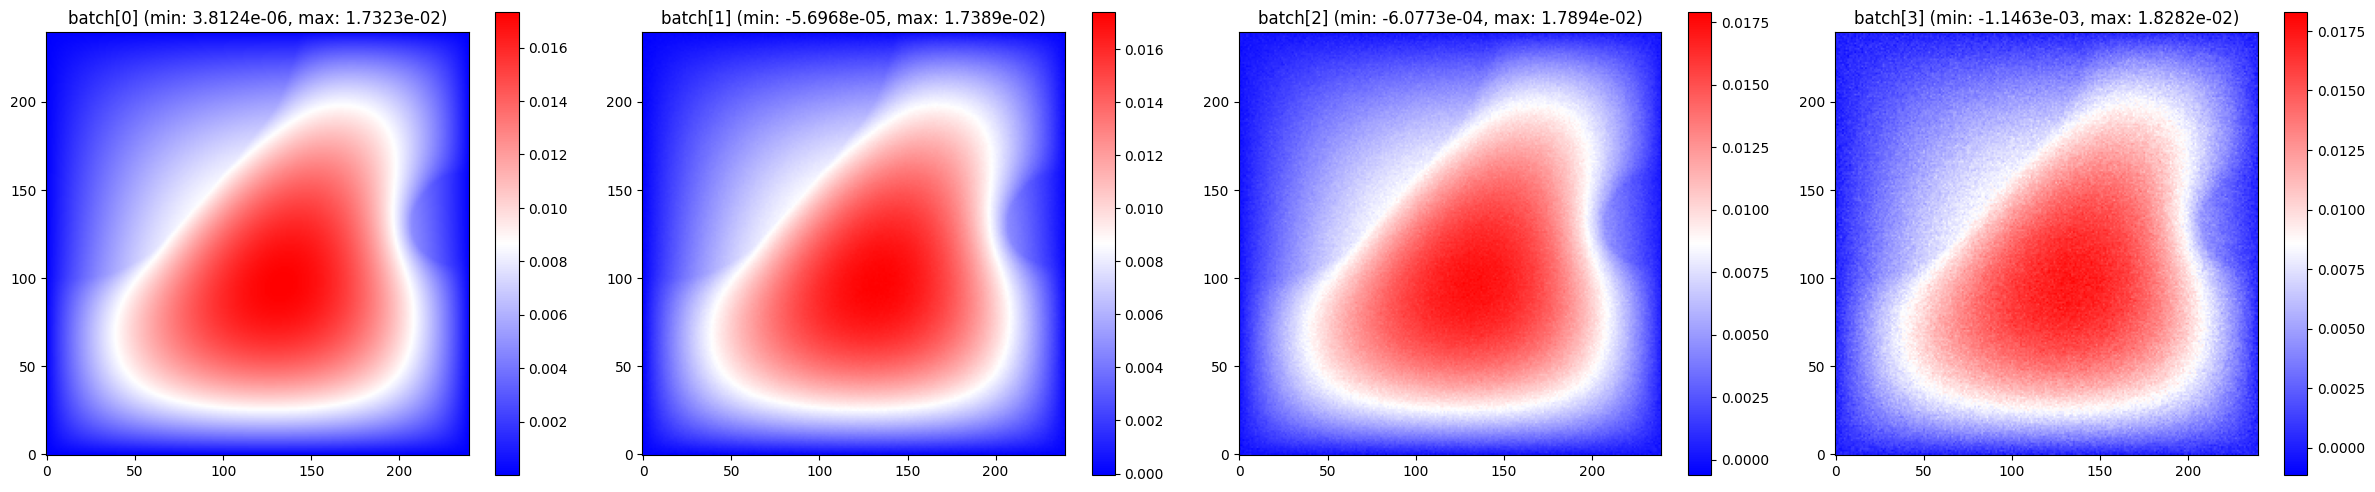

In [21]:
def get_noisy_data(u, noise_levels, std: float):
    # u shape: (1, 1, H, W) or (1, C, H, W)
    device = u.device
    dtype = u.dtype
    
    # Convert noise_levels to tensor
    noise_levels_tensor = torch.tensor(noise_levels, dtype=dtype, device=device).view(-1, 1, 1, 1)
    noise_stds = noise_levels_tensor * float(std)
    
    # Repeat u for each noise level
    u_expanded = u.repeat(len(noise_levels), 1, 1, 1)  # [3, 1, 240, 240]
    
    # Create and apply noise
    noise = torch.randn_like(u_expanded) * noise_stds
    u_noisy = u_expanded + noise
    assert u_noisy.shape[0] == len(noise_levels)
    return u_noisy
u = batch["darcy"]
print("u shape:", u.shape)
noise_levels = [0.01, 0.05, 0.1]
u_noisy = get_noisy_data(u, noise_levels, std=3.88433e-03)
for i in range(len(noise_levels)):
    print("Sample shape:", u_noisy[i].shape, "max:", u_noisy[i].max().item(), "min:", u_noisy[i].min().item())

print("u_noisy shape:", u_noisy.shape)

plot_batch([u] + [u_noisy[i] - u for i in range(len(noise_levels))])
plot_batch([u] + [u_noisy[i].unsqueeze(0) for i in range(len(noise_levels))])

(2, 3)
[<Axes: > <Axes: > <Axes: >]


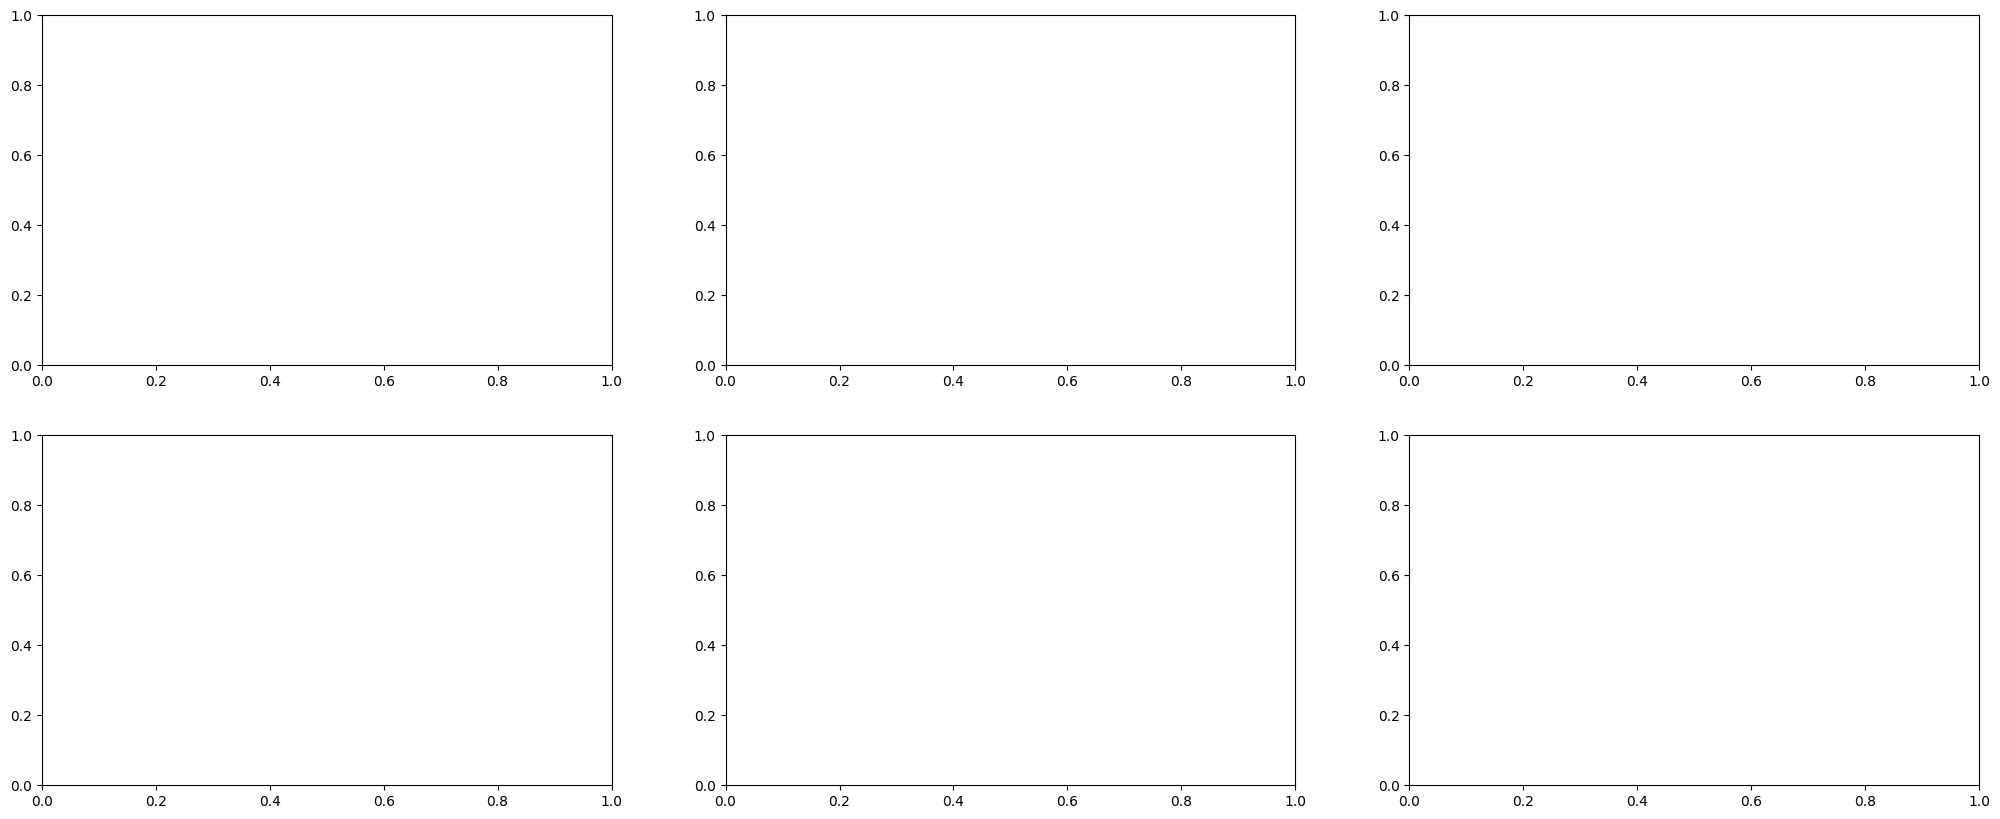

In [1]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 3, figsize=(25, 10))
print(ax.shape)
print(ax[0])